CUstomers length: 100, n_dyn: 40, dynamic_ids: [2, 4, 9, 11, 12, 14, 16, 18, 22, 23, 27, 31, 35, 36, 37, 41, 42, 43, 45, 46, 48, 53, 54, 57, 65, 66, 69, 71, 72, 77, 79, 80, 82, 83, 86, 93, 95, 96, 97, 98]
service_start: 14217, c.due_time: 13100.0, completion_time: 15217, lateness: 1117.0
Customer 65 is late.
service_start: 17329, c.due_time: 15700.0, completion_time: 18329, lateness: 1629.0
Customer 45 is late.
service_start: 17203, c.due_time: 16300.0, completion_time: 18203, lateness: 903.0
Customer 36 is late.
service_start: 17955, c.due_time: 15500.0, completion_time: 18955, lateness: 2455.0
Customer 14 is late.
service_start: 20173, c.due_time: 18000.0, completion_time: 21173, lateness: 2173.0
Customer 72 is late.
service_start: 23511, c.due_time: 22500.0, completion_time: 24511, lateness: 1011.0
Customer 83 is late.
service_start: 23942, c.due_time: 22000.0, completion_time: 24942, lateness: 1942.0
Customer 95 is late.
service_start: 27259, c.due_time: 27200.0, completion_time: 2

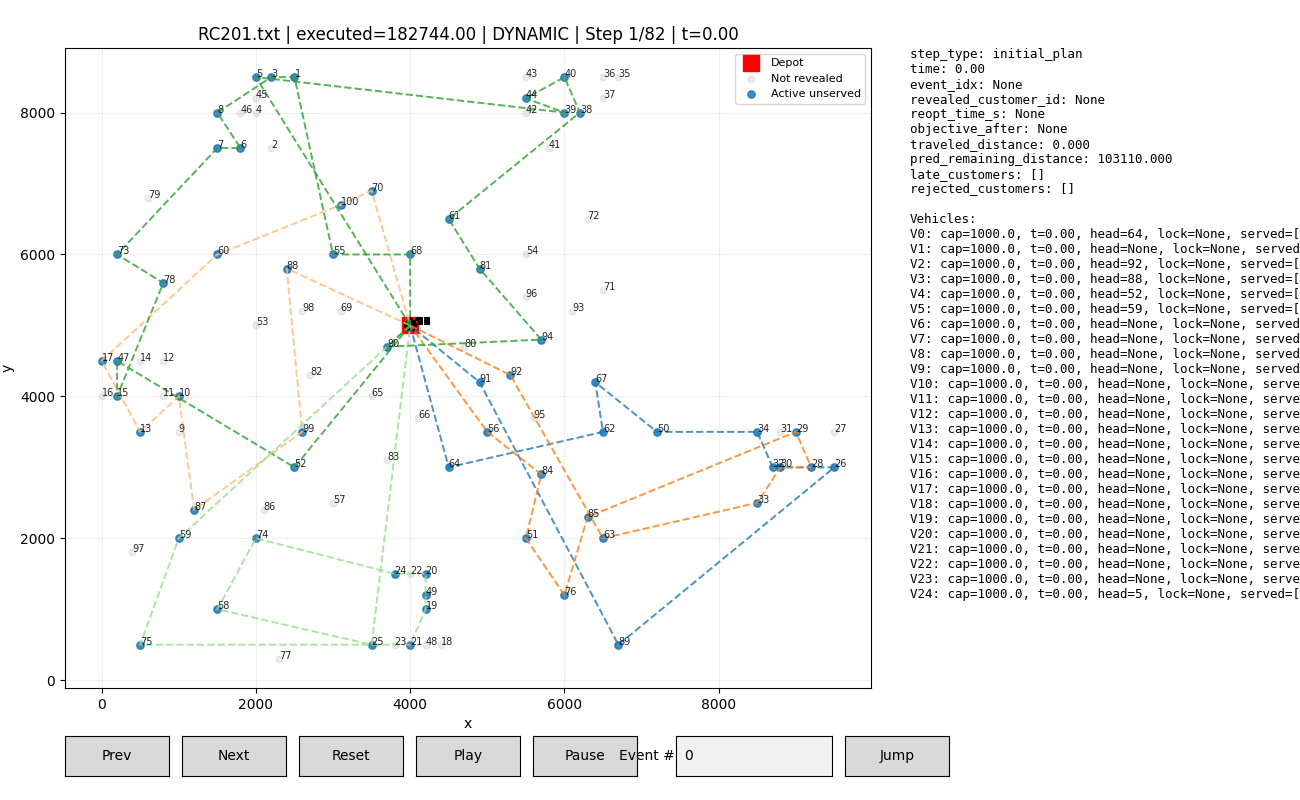

In [1]:
%matplotlib widget
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.viz.inspector import inspect_dynamic
from dvrptw_bench.heuristics.ortools_dynamic import ORToolsDVRPTWSolver

from pathlib import Path

from pyarrow import dataset

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon

dataset_path = Path("../../dataset/solomon_rc100")
instances = [parse_solomon(instance, max_customers=100, distance_scale=100) for instance in find_rc_instances(dataset_path)]
dod = 0.4
cutoff = 0.99
budget_s = 0.1
end_time_closeness = 0.9
soft_time_windows = True
# dynamic_instances = [build_dynamic_scenario(instance, epsilon=dod, seed=42) for instance in instances]

sim = DynamicSimulator(instances[0])
# res = sim.run(lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(True).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
# print(res[0].violations)
# res = sim.run(lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(False).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff)
# print(res[0].violations)
inspect_dynamic(instances[0], sim, lambda instance, time_limit_s, warm_start = None: ORToolsDVRPTWSolver(soft_time_windows).solve(instance, time_limit_s, warm_start), budget_s=budget_s, epsilon=dod, seed=15, cutoff_ratio=cutoff, end_time_closeness=end_time_closeness)



In [2]:
from dvrptw_bench.viz.inspector import inspect_static
from dvrptw_bench.viz.route_plot import plot_routes

# plot_routes(instances[0], res[0])

In [3]:
%matplotlib widget
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.viz.inspector import inspect_static
ortoolsSolver = ORToolsVRPTWSolver()
sol = ortoolsSolver.solve(instances[0], time_limit_s=10)

# inspect_static(instances[0], sol)
# inspect_static(instances[0], ORToolsVRPTWSolver().solve(instances[0], time_limit_s=10))